In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
t = words
chrs = sorted(list(set(''.join(t))))
stoi = {}
itos = {}
for i,ch in enumerate(chrs):
    stoi[ch] = i+1
    itos[i+1] = ch

stoi['.'] = 0
itos[0] = '.'

# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos, len(words))

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'} 32033


In [6]:
# build the dataset
# lets define block_size = k, the number of characters that would feed into this neural network.
block_size = 3

def build_dataset(words):
    # Rolling window dataset: 
    context = [stoi['.']] *  block_size
    X, Y  = [], []
    
    for w in words[:]:
        chrs = list(w) + ['.']
        for ch in chrs:
            #print(context, ch)
            X.append(context)
            Y.append(stoi[ch])
            context = context[1:] + [stoi[ch]]
    # for x, y in zip(X, Y):
    #     print(''.join([itos[k] for k in x]), itos[y])
    
    Xt, Yt = torch.tensor(X), torch.tensor(Y)
    print(Xt.shape, Yt.shape)
    return Xt, Yt

# random shuffle
import random
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtrain, Ytrain = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

torch.Size([182466, 3]) torch.Size([182466])
torch.Size([22873, 3]) torch.Size([22873])
torch.Size([22807, 3]) torch.Size([22807])


In [132]:
# context manager with @pytorch.nograd() decorator
## Respectable concise version: 
# Declaration: 

g = torch.Generator().manual_seed(2147483647)

# Hyperparams:
vocab_size = len(itos) # 27
n_embed = 10 # start with 2 for visualization purposes. 
n_hidden = 200

# Embedding lookup table C
C = torch.randn((vocab_size, n_embed),                  generator=g)

# hidden layer hyper params
w1_size = n_hidden
b1_size = n_hidden
W1 = torch.randn((block_size * n_embed, w1_size),      generator=g) * (5/3) / ((n_embed * block_size) **0.5)
B1 = torch.randn(b1_size,                              generator=g) * 0.001
print(W1.shape, B1.shape)

W2 = torch.randn((W1.shape[1], vocab_size),            generator=g) * 0.01
B2 = torch.randn(vocab_size,                           generator=g) * 0
parameters = [C, W1, B1, W2, B2]

# Batch norm for the first hidden layer
bngain = torch.ones((1, w1_size)) # we will broadcast this
bnbias = torch.zeros((1, w1_size))

bnmean_running = torch.zeros((1, w1_size))
bnstd_running = torch.ones((1, w1_size))

# requires grad
for p in parameters:
    p.requires_grad = True

sum(p.nelement() for p in parameters)

torch.Size([30, 200]) torch.Size([200])


11897

In [133]:
print((B1**2).mean().sqrt())
print((W1**2).mean().sqrt())
print((W2**2).mean().sqrt())
print((B2**2).mean().sqrt())

tensor(0.0010, grad_fn=<SqrtBackward0>)
tensor(0.3107, grad_fn=<SqrtBackward0>)
tensor(0.0100, grad_fn=<SqrtBackward0>)
tensor(0., grad_fn=<SqrtBackward0>)


In [135]:
# Forward pass, backward pass and update (grad)

lossi = []
stepi= []
lri = []
batch_size = 32
num_steps = 200000

input_vector_size = block_size * n_embed
for i in range(num_steps):
    ix = torch.randint(0, Xtrain.shape[0], (batch_size, ))
    emb  = C[Xtrain[ix]]
    h_pre = emb.view(-1, input_vector_size) @ W1 + B1
    
    # h_norm add batch normalization here
    bnmeani = h_pre.mean(0, keepdims=True)
    bnstdi = h_pre.std(0, keepdims=True)
    h_pre = (h_pre - bnmeani) / bnstdi
    h_bn = h_pre * bngain + bnbias
    h = torch.tanh(h_bn)
    logits = h @ W2 + B2
    
    c =  logits.exp()
    probs = c / c.sum(1, keepdims=True)
    # probs.shape
    # loss = -probs[torch.arange(probs.shape[0]), Yt].log().mean()
    loss = torch.nn.functional.cross_entropy(logits, Ytrain[ix])

    # Calculate the running bngain and bnbias
    with torch.no_grad():
        bnmean_running = bnmean_running * 0.99 + bnmeani * 0.01
        bnstd_running = bnstd_running * 0.99 + bnstdi * 0.01
    
    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # Gradient descent update
    #lr = lrs[i]
    #lri.append(lr)
    lr = 0.1 if i < 100000 else 0.01
    # lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

    #print(loss.item())
    lossi.append(loss.log10().item())
    stepi.append(i)

    if i % 10000 == 0:
        print(f'{i:7d}/{num_steps:7d}: {loss.item():.4f}')
        

# much better to have an approximate gradient and take more steps than an exact gradient and take fewer steps.
print(10**lossi[-1])

      0/ 200000: 3.2932
  10000/ 200000: 2.0925
  20000/ 200000: 2.1876
  30000/ 200000: 2.3783
  40000/ 200000: 2.6851
  50000/ 200000: 2.6193
  60000/ 200000: 2.2930
  70000/ 200000: 2.3012
  80000/ 200000: 2.1700
  90000/ 200000: 2.2477
 100000/ 200000: 2.2132
 110000/ 200000: 1.9440
 120000/ 200000: 2.0508
 130000/ 200000: 2.2571
 140000/ 200000: 1.9237
 150000/ 200000: 2.5227
 160000/ 200000: 2.2225
 170000/ 200000: 2.4199
 180000/ 200000: 2.2965
 190000/ 200000: 1.8212
2.3866887481251315


(array([  1.,   0.,   1.,   0.,   0.,   0.,   0.,   1.,   1.,   1.,   1.,
          2.,   1.,   2.,   3.,   2.,   2.,   5.,   9.,   8.,   9.,   9.,
          8.,  15.,  16.,  18.,  27.,  26.,  24.,  37.,  40.,  35.,  50.,
         52.,  65.,  56.,  76., 106.,  93.,  92., 117., 121., 133., 125.,
        144., 144., 158., 157., 153., 197., 193., 188., 186., 181., 208.,
        176., 176., 151., 183., 182., 170., 164., 135., 144., 108., 121.,
        112.,  81.,  87.,  83.,  81.,  73.,  66.,  58.,  53.,  34.,  37.,
         36.,  25.,  29.,  25.,  15.,  22.,  13.,   8.,  12.,   8.,   5.,
          3.,   6.,   2.,   2.,   6.,   1.,   4.,   1.,   0.,   0.,   1.,
          2.]),
 array([-1.92018354, -1.88429128, -1.84839902, -1.81250677, -1.77661451,
        -1.74072225, -1.70482999, -1.66893774, -1.63304548, -1.59715322,
        -1.56126096, -1.5253687 , -1.48947645, -1.45358419, -1.41769193,
        -1.38179967, -1.34590742, -1.31001516, -1.2741229 , -1.23823064,
        -1.20233839, -1.16

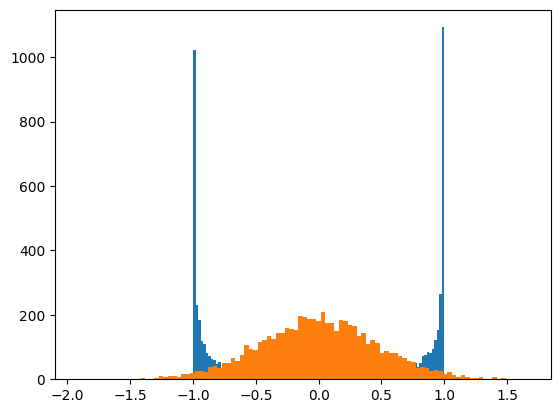

In [121]:

# plot histogram of h
plt.hist(h.view(-1).tolist(), 100)
plt.hist(W1.view(-1).tolist(), 100)

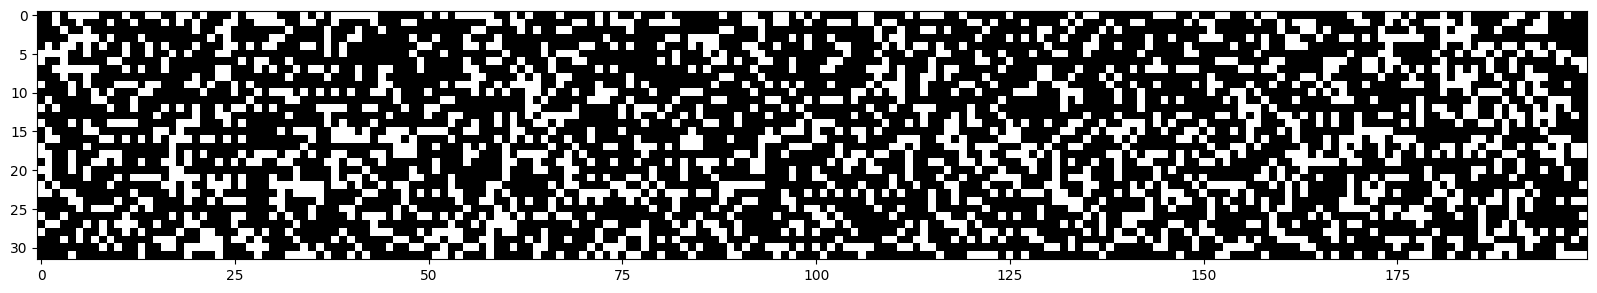

In [136]:
plt.figure(figsize=(20,10))
plt.imshow(h_pre.abs()> 0.99, cmap='gray', interpolation='nearest')

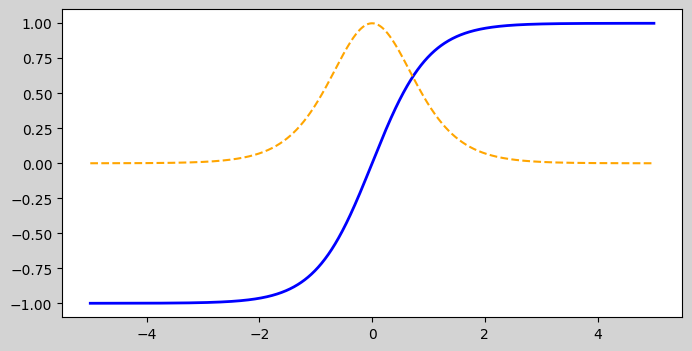

In [61]:
import numpy as np
ff = torch.linspace(-5,5,1000)
y_derivative = 1 - np.tanh(ff.tolist())**2
plt.figure(figsize=(8,4), facecolor='lightgray')
plt.plot(ff, torch.tanh(ff), label="tanh", color='blue', linewidth=2)
plt.plot(ff, y_derivative, label="d(tanh)", color='orange', linestyle='--')
plt.show()

In [117]:
# gaussian experiments. randn() generates from a gaussian distribution with a standard deviation of 1, mean around 0
a1 = torch.randn((10,100))
print(a1.mean(), a1.std())

b1 = torch.randn((100, 5))
print(b1.mean(), b1.std())
c1 = a1@b1
print(c1.mean(), c1.std())

tensor(-0.0166) tensor(1.0700)
tensor(-0.0761) tensor(0.9825)
tensor(0.1246) tensor(10.0855)


In [138]:
#plt.plot(lossi)
@torch.no_grad()
def split_loss(split):
    x, y = {
    'train': (Xtrain, Ytrain),
    'val': (Xdev, Ydev),
    'test': (Xtest, Ytest),
       }[split]
    emb = C[x] # (N, block_size, n_embd)
      # This is cool, wherever we have -1, its inferred from other dimensions.
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    h_r = embcat @ W1 + B1
    h_r = (h_r - bnmean_running) / bnstd_running
    h_b = h_r * bngain + bnbias
    h = torch.tanh(h_b) # (N, n_hidden)
    logits = h @ W2 + B2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0918326377868652
val 2.124657154083252
